In [1]:
#basics
import os
import warnings
import math
import numpy as np
import pandas as pd
import seaborn as sns
import tqdm
import sys

#plotting
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

#datasets
from sklearn.datasets import load_iris
from robpy import datasets

In [2]:
sys.path.append(os.path.abspath("..")) 
from bixplot import bixplot, pamc1d, bixplot_methods

In [3]:
os.makedirs("visual", exist_ok=True)

# Datasets

In [4]:
########################### simulated data
np.random.seed(123)
n = 100
d = {"Unimodal": np.random.normal(0, 1.5, n),
     "Bimodal": np.concatenate([np.random.normal(2, 0.9, n // 2),np.random.normal(-2, 0.9, n // 2)]),
     "Multimodal": np.concatenate([np.random.normal(2.5, 0.6, n // 3), np.random.normal(0, 0.6, n // 3), np.random.normal(-2.5, 0.6, n // 3)])}
df_simulated = pd.concat([pd.DataFrame({"Value": v, "Distribution": k}) for k, v in d.items()], ignore_index=True)
print(df_simulated.shape)
display(df_simulated.head(2))

(299, 2)


,Value,Distribution
0,-1.628446,Unimodal
1,1.496018,Unimodal


In [5]:
########################### behavioural data
#from: Kerr, N. R. and T. Ingram (2021). Personality does not predict individual niche variation 
#in a freshwater fish. Behavioral Ecology 32 (1), 159–167
df_beh = pd.read_csv(os.path.join('data', 'BehaviourTrials.csv'))
df_beh['Round'] = df_beh['Round'].map(lambda x: 'round '+str(x))
print(df_beh.shape)
display(df_beh.head(2))

(120, 7)


,ID,Tank,Round,Boldness_TimeInRefuge,Boldness_LatencyToApproach,Exploration_LatencyToEnter,Aggression
0,1,3,round 1,56.0,15.0,26.0,212.0
1,3,3,round 1,300.0,5.0,300.0,22.0


In [6]:
########################### Iris data 
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['species'] = [iris.target_names[i] for i in iris.target]

# Standardize only the four features to compare them along same axis
df_iris[iris.feature_names] = (df_iris[iris.feature_names] - df_iris[iris.feature_names].mean()) / df_iris[iris.feature_names].std(ddof=0)

# Rename columns to R-style naming
df_iris = df_iris.rename(columns={'sepal length (cm)': 'Sepal.L', 'sepal width (cm)': 'Sepal.W', 
                                  'petal length (cm)': 'Petal.L', 'petal width (cm)': 'Petal.W'})
print(df_iris.shape)
display(df_iris.head(2))

# melt into long format for violin plotting
df_plt_iris = pd.melt(df_iris, id_vars='species', value_vars=['Sepal.L', 'Sepal.W', 'Petal.L', 'Petal.W'], 
                      var_name="feature", value_name="standardized value").copy()
print(df_plt_iris.shape)
display(df_plt_iris.head(2))

(150, 5)


,Sepal.L,Sepal.W,Petal.L,Petal.W,species
0,-0.900681,1.019004,-1.340227,-1.315444,setosa
1,-1.143017,-0.131979,-1.340227,-1.315444,setosa


(600, 3)


,species,feature,standardized value
0,setosa,Sepal.L,-0.900681
1,setosa,Sepal.L,-1.143017


In [7]:
########################### penguins data
df_penguins = sns.load_dataset("penguins")
df_penguins.rename(columns={'bill_length_mm':'bill_length', 'bill_depth_mm':'bill_depth', 
                            'flipper_length_mm':'flipper_length','body_mass_g':'body_mass'}, inplace=True)
print(df_penguins.shape)
display(df_penguins.head(2))

(344, 7)


,species,island,bill_length,bill_depth,flipper_length,body_mass,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female


In [8]:
########################### TopGear data
bunch = datasets.load_topgear()
df_tg = pd.DataFrame(bunch.data, columns=bunch.feature_names)
df_tg['log(Price)'] = df_tg['Price'].map(lambda x: np.log(x))
display(df_tg.head(2))
print(df_tg.shape)

,Make,Model,Type,Fuel,Price,Cylinders,Displacement,DriveWheel,BHP,Torque,...,CruiseControl,ElectricSeats,Leather,ParkingSensors,PowerSteering,SatNav,ESP,Verdict,Origin,log(Price)
0,Alfa Romeo,Giulietta,Giulietta 1.6 JTDM-2 105 Veloce 5d,Diesel,21250.0,4.0,1598.0,Front,105.0,236.0,...,standard,optional,optional,optional,standard,optional,standard,6.0,Europe,9.964112
1,Alfa Romeo,MiTo,MiTo 1.4 TB MultiAir 105 Distinctive 3d,Petrol,15155.0,4.0,1368.0,Front,105.0,95.0,...,standard,no,optional,standard,standard,optional,standard,5.0,Europe,9.626086


(297, 33)


In [9]:
########################### titanic data
df_titanic = sns.load_dataset("titanic") #pd.read_csv(os.path.join("data", "titanic.csv"))
display(df_titanic.head(2))
print(df_titanic.shape)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False


(891, 15)


In [10]:
########################### birds data
df_birds = pd.read_csv(os.path.join("data", "AVONET Supplementary dataset 1.csv"))
display(df_birds.head(2))
print(df_birds.shape)

,Sequence,Species1,Family1,Order1,Avibase.ID1,Total.individuals,Female,Male,Unknown,Complete.measures,...,Habitat.Density,Migration,Trophic.Level,Trophic.Niche,Primary.Lifestyle,Min.Latitude,Max.Latitude,Centroid.Latitude,Centroid.Longitude,Range.Size
0,3103.0,Accipiter albogularis,Accipitridae,Accipitriformes,AVIBASE-BBB59880,5,2,0,3,4,...,1,2.0,Carnivore,Vertivore,Insessorial,-11.73,-4.02,-8.15,158.49,37461.21
1,3090.0,Accipiter badius,Accipitridae,Accipitriformes,AVIBASE-1A0ECB6E,10,4,6,0,8,...,2,3.0,Carnivore,Vertivore,Insessorial,-29.47,46.39,8.23,44.98,22374973.00


(11009, 37)


In [11]:
#define collors to sometimes stay consistent with R 
R_orange = '#E49E69'
R_pink = '#E07CA3'
R_blue = '#8FC9D2'
R_green = '#B2FF66'

# Violinplot & bixplot on simulated data (Fig.2)

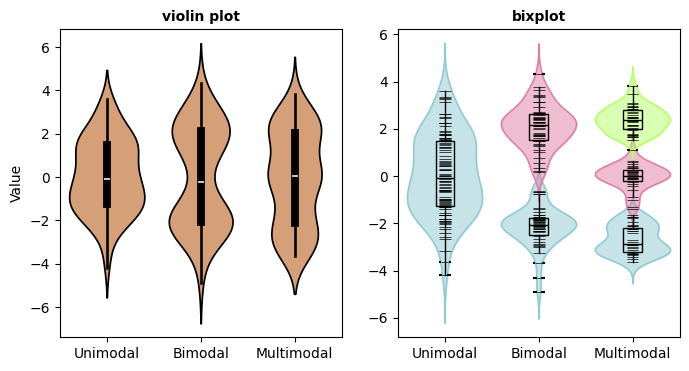

In [12]:
fig, axs = plt.subplots(1,2, figsize=(8, 4))
li_order = ["Unimodal","Bimodal","Multimodal"]
sns.violinplot(data=df_simulated, x='Distribution', y='Value', orient='v', order=li_order, 
               color=R_orange, linecolor="k", ax=axs[0])
axs[0].set_title('violin plot', size=10, fontweight='bold')
axs[0].set_xlabel('')

r = bixplot(data=df_simulated, x='Distribution', y='Value', orient='v',  group_order=li_order,
            mode_color=[R_blue, R_pink,R_green], rug_linewidths=0.5, ax=axs[1])
axs[1].set_title('bixplot', size=10, fontweight='bold')
axs[1].set_ylabel('')
axs[1].set_xlabel('');

# Violinplot & Bixplot latency & penguins (Fig. 3)

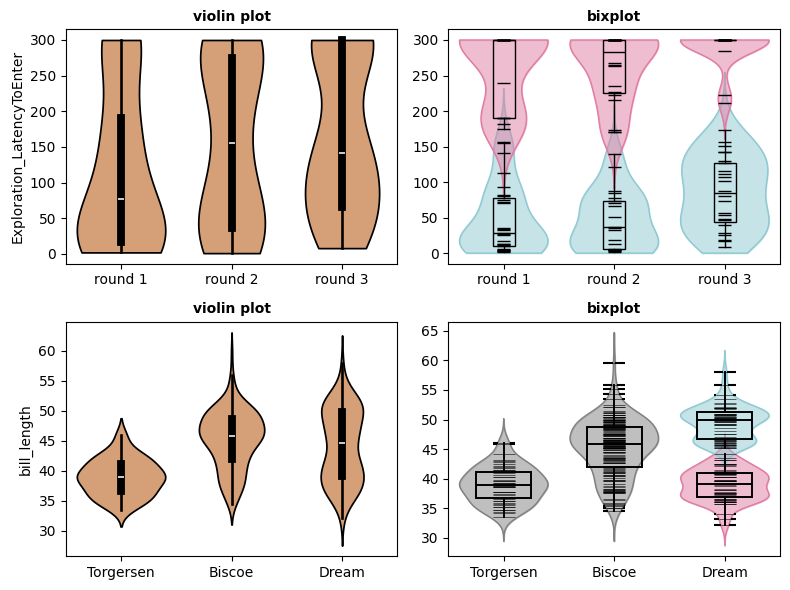

In [13]:
fig, axs = plt.subplots(2,2, figsize=(8, 6))

##########################################################################################################
### Exploratory behaviour 
##########################################################################################################    
sns.violinplot(data=df_beh, x='Round', y='Exploration_LatencyToEnter', color=R_orange, cut=0, linecolor="k", 
               ax=axs[0, 0])
axs[0,0].set_xlabel('')
axs[0,0].set_title("violin plot", fontweight='bold', fontsize=10)

bixplot(data=df_beh, x='Round', y='Exploration_LatencyToEnter', mode_color=[R_blue, R_pink,R_green], 
        cut=3, cutmin=0, cutmax=300, ax=axs[0, 1])
axs[0,1].set_ylabel('')
axs[0,1].set_xlabel('')
axs[0,1].set_title("bixplot", fontweight='bold', fontsize=10)

##########################################################################################################
### penguins
##########################################################################################################
sns.violinplot(data=df_penguins, x='island', y='bill_length', color=R_orange, linecolor="k", ax=axs[1, 0])
axs[1,0].set_xlabel('')
axs[1,0].set_title("violin plot", fontweight='bold', fontsize=10)

bixplot(data=df_penguins, x='island', y='bill_length', group_order=['Torgersen','Biscoe','Dream'], 
        mode_color=['grey', R_pink, R_blue, 'grey'], mode_color_by_suffix=False,
        rug_length=0.20, rug_linewidths=0.4, 
        box_width=2.5, box_color='black', box_linewidth=1.4,
        ax=axs[1, 1])
axs[1,1].set_ylabel('')
axs[1,1].set_xlabel('')
axs[1,1].set_title("bixplot", fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join("visual","latency+billength_python.png"), dpi=300, bbox_inches='tight')

# Exploring the iris (Fig. 4)

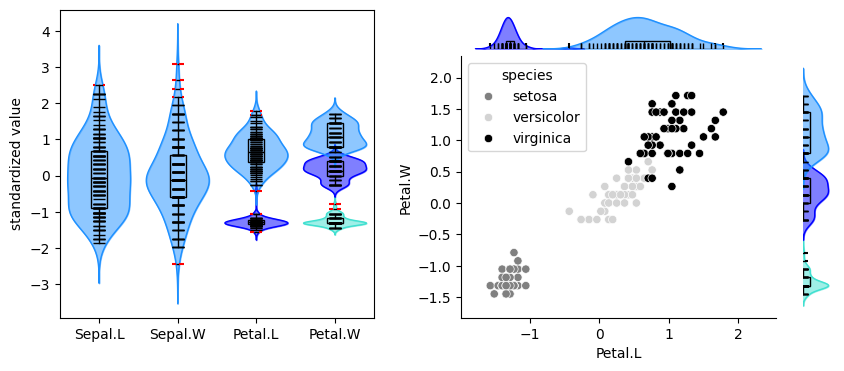

In [14]:
fig = plt.figure(figsize=(10, 4))
gs = GridSpec(2, 4, width_ratios=[2, 0.2, 2, 0.2], height_ratios=[0.3, 2], wspace=0.16, hspace=0.05)

################### --- Left Panel: Violin Plots ---
ax_violin = fig.add_subplot(gs[:, 0])
bixplot(data=df_plt_iris, x='feature', y='standardized value', group_order=['Sepal.L','Sepal.W','Petal.L','Petal.W'], 
        rug_length=0.15, rug_outer_color='red',
        mode_color={'Petal.L_0':'blue', 'Petal.L_1':'dodgerblue', 
                    'Petal.W_0':'turquoise','Petal.W_1':'blue','Petal.W_2':'dodgerblue',
                    'Sepal.L_0':'dodgerblue','Sepal.W_0':'dodgerblue'}, 
        mode_color_by_suffix=False, ax=ax_violin)
plt.xlabel('')

################### --- Right Main: Petal.L vs Petal.W ---
ax_main = fig.add_subplot(gs[1, 2])
sns.scatterplot(data=df_iris, x='Petal.L', y='Petal.W', hue='species', 
                palette={'setosa':'grey','versicolor':'lightgrey', 'virginica':'black'}, ax=ax_main)
sns.despine(ax=ax_main)

# --- Top Marginal: Petal.L
ax_top = fig.add_subplot(gs[0, 2], sharex=ax_main)
bixplot(data=df_iris, x='Petal.L', orient='h', ax=ax_top, rug_length=0.15,
        mode_color={'Petal.L_0':'blue', 'Petal.L_1':'dodgerblue',
                    'Petal.W_0':'turquoise','Petal.W_1':'blue','Petal.W_2':'dodgerblue',
                    'Sepal.L_0':'dodgerblue','Sepal.W_0':'dodgerblue'},
        mode_color_by_suffix=False)
ymin, ymax = ax_top.get_ylim()
cutpoint = (ymax-ymin) / 2
ax_top.set_ylim(cutpoint+ymin, ymax)
ax_top.axis('off')

# --- Right Marginal: Petal.W
ax_right = fig.add_subplot(gs[1, 3], sharey=ax_main)
bixplot(data=df_iris, y='Petal.W', orient='v', ax=ax_right, rug_length=0.15, 
        mode_color={'Petal.L_0':'blue', 'Petal.L_1':'dodgerblue',
                    'Petal.W_0':'turquoise','Petal.W_1':'blue','Petal.W_2':'dodgerblue',
                    'Sepal.L_0':'dodgerblue','Sepal.W_0':'dodgerblue'},
        mode_color_by_suffix=False)
xmin, xmax = ax_right.get_xlim()
cutpoint = (xmax - xmin) / 2
ax_right.set_xlim(cutpoint + xmin, xmax)
ax_right.axis('off');

sample size:  120


,Species1,feature,standardized value
0,Actenoides bougainvillei,Tail.Length,0.668351
1,Actenoides capucinus,Tail.Length,1.167029


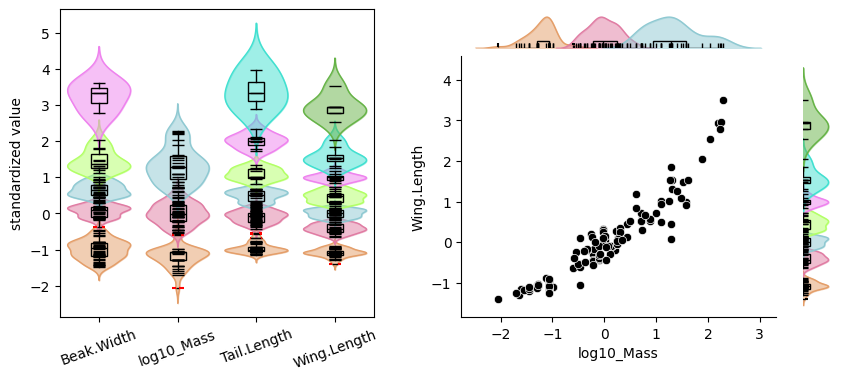

In [15]:
#Kinfisher example
# melt into long format for violin plotting
df_plt_birds_ = df_birds[(df_birds['Family1']=='Alcedinidae')&(df_birds["Mass"]>0)].copy()
df_plt_birds_["log10_Mass"] = np.log10(df_plt_birds_["Mass"])
print('sample size: ', df_plt_birds_.shape[0])
# Standardize only the four features to compare them along same axis
feature_names = ['Tail.Length', 'Beak.Width', 'Wing.Length', 'log10_Mass']
df_plt_birds_[feature_names] = (df_plt_birds_[feature_names] - df_plt_birds_[feature_names].mean()) / df_plt_birds_[feature_names].std(ddof=0)
df_plt_birds = pd.melt(df_plt_birds_, id_vars='Species1', value_vars=['Tail.Length', 'Wing.Length', 'log10_Mass', 'Beak.Width'], 
                      var_name="feature", value_name="standardized value").copy()
display(df_plt_birds.head(2))

#################################### Visual
fig = plt.figure(figsize=(10, 4))
gs = GridSpec(2, 4, width_ratios=[2, 0.2, 2, 0.2], height_ratios=[0.3, 2], wspace=0.16, hspace=0.05)
li_col = [R_orange, R_pink, R_blue, R_green, 'violet', "turquoise", "#66B347"]

################### --- Left Panel: Violin Plots ---
ax_violin = fig.add_subplot(gs[:, 0])
bixplot(data=df_plt_birds, x='feature', y='standardized value', group_order=['Beak.Width','Sepal.W','log10_Mass','Wing.LengthWing.Length'], 
        rug_length=0.15, rug_outer_color='red',ax=ax_violin, mode_color=li_col, undo_constrainkmax=True)
ax_violin.tick_params(axis='x', labelrotation=20)
plt.xlabel('')

################### --- Right Main: log10_Mass vs Wing.Length ---
ax_main = fig.add_subplot(gs[1, 2])
sns.scatterplot(data=df_plt_birds_, x='log10_Mass', y='Wing.Length', ax=ax_main, color='black')
sns.despine(ax=ax_main)

# --- Top Marginal: log10_Mass
ax_top = fig.add_subplot(gs[0, 2], sharex=ax_main)
bixplot(data=df_plt_birds_, x='log10_Mass', orient='h', ax=ax_top, rug_length=0.15, mode_color=li_col, undo_constrainkmax=True)
ymin, ymax = ax_top.get_ylim()
cutpoint = (ymax-ymin) / 2
ax_top.set_ylim(cutpoint+ymin, ymax)
ax_top.axis('off')

# --- Right Marginal: Wing.Length
ax_right = fig.add_subplot(gs[1, 3], sharey=ax_main)
bixplot(data=df_plt_birds_, y='Wing.Length', orient='v', ax=ax_right, rug_length=0.15, mode_color=li_col, undo_constrainkmax=True)
xmin, xmax = ax_right.get_xlim()
cutpoint = (xmax - xmin) / 2
ax_right.set_xlim(cutpoint + xmin, xmax)
ax_right.axis('off');
plt.savefig(os.path.join("visual","kingfisher_python.png"), dpi=300, bbox_inches='tight')

# Normalising density on iris (Fig. 5)

The bixplot supports different rules for scaling density width: with 'count', all violins have equal width, with 'area', all violins have the same area and with 'count', width is proportional to the number of observations 

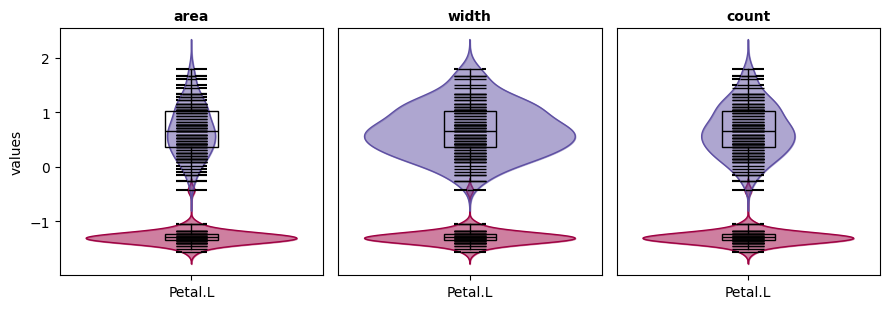

In [16]:
fig, axs = plt.subplots(1,3, figsize=(9, 3.2))
r = bixplot(data=df_iris, y='Petal.L', density_norm='area', ax=axs[0])
axs[0].set_xlabel('')
axs[0].set_title('area', size=10, fontweight='bold')

r = bixplot(data=df_iris, y='Petal.L', density_norm='width', ax=axs[1])
axs[1].set_ylabel('')
axs[1].set_yticks([]) 
axs[1].set_xlabel('')

axs[1].set_title('width', size=10, fontweight='bold')
r = bixplot(data=df_iris, y='Petal.L', density_norm='count', ax=axs[2])
axs[2].set_ylabel('')
axs[2].set_yticks([]) 
axs[2].set_xlabel('')
axs[2].set_title('count', size=10, fontweight='bold')
plt.tight_layout()

In the Python implementation, the density normalization accounts for all densities within any group, that is, the normalization of one mode depends on all other modes, as illustrated in the figure below.

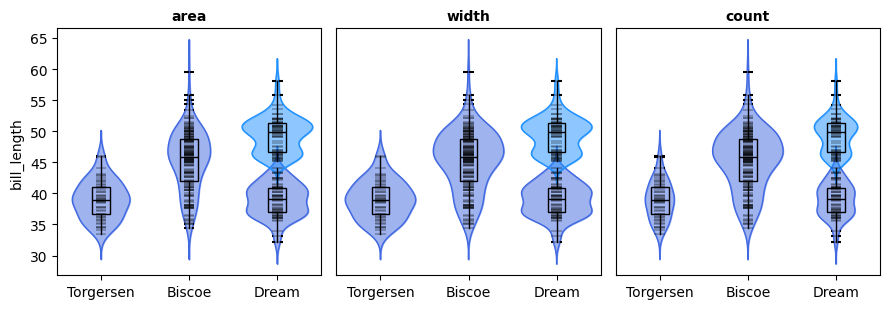

In [17]:
fig, axs = plt.subplots(1,3, figsize=(9, 3.2))
r = bixplot(data=df_penguins, x='island', y='bill_length', group_order=['Torgersen', 'Biscoe', 'Dream'],
            mode_color=['royalblue','dodgerblue', 'blue', 'turquoise'],
            density_norm='area', rug_linewidths=0.35,  ax=axs[0])
axs[0].set_xlabel('')
axs[0].set_title('area', size=10, fontweight='bold')

r = bixplot(data=df_penguins, x='island', y='bill_length', group_order=['Torgersen', 'Biscoe', 'Dream'], 
            mode_color=['royalblue','dodgerblue', 'blue', 'turquoise'],
            density_norm='width', rug_linewidths=0.35, ax=axs[1])
axs[1].set_ylabel('')
axs[1].set_yticks([]) 
axs[1].set_xlabel('')
axs[1].set_title('width', size=10, fontweight='bold')

r = bixplot(data=df_penguins, x='island', y='bill_length', group_order=['Torgersen', 'Biscoe', 'Dream'],
            mode_color=['royalblue','dodgerblue', 'blue', 'turquoise'], 
            density_norm='count',rug_linewidths=0.35, ax=axs[2])
axs[2].set_ylabel('')
axs[2].set_yticks([]) 
axs[2].set_xlabel('')
axs[2].set_title('count', size=10, fontweight='bold')
plt.tight_layout()

# Split option in penguin (Fig. 6)

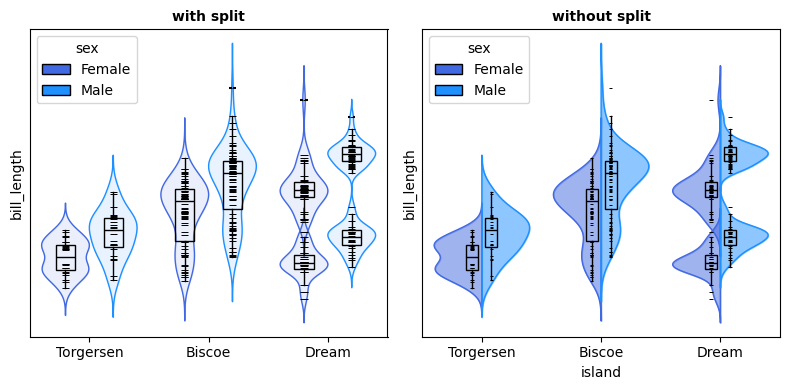

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
r = bixplot(data=df_penguins, x='island', y='bill_length', group_order=['Torgersen', 'Biscoe', 'Dream'],
            hue='sex', hue_color=['royalblue','dodgerblue'], split=False, density_color='hue', 
            density_alpha=0.1, box_width=1.6,
            rug_linewidths=0.7, ax=axs[0])
axs[1].set_title('without split', size=10, fontweight='bold')
axs[1].set_ylabel('')
axs[1].set_yticks([]) 
axs[1].set_xlabel('')

r = bixplot(data=df_penguins, x='island', y='bill_length', group_order=['Torgersen', 'Biscoe', 'Dream'], 
            hue='sex', hue_color=['royalblue','dodgerblue'], split=True, density_color='hue', 
            rug_linewidths=0.7, ax=axs[1])
axs[0].set_xlabel('')
axs[0].set_title('with split', size=10, fontweight='bold')
plt.tight_layout()

# Colour options (Fig. 7)

In the python implementation, the colors that will reflect the identified modes (controlled by mode_color and mode_color_by_suffix, see second figure in this section for more details) can be applied to either the density plot (density_color='mode') the boxplot (box_color='mode'), or both (density_color='mode', box_color='mode', see third figure in this section, top row.
Similarly, when the rug_hue argument is provided, its colors (controlled by hue_color, for both continuous and categorical variables, see first figure in this section left and right side, respectively) can be applied to the density plot (density_color='hue'), the boxplot (box_color='hue'), or both, see the bottom row of the third figure in this section for more details.

In [19]:
df_plt_penguins = df_penguins.copy()
df_plt_penguins[["bill_length","bill_depth",
                 "flipper_length"]] = (df_plt_penguins[["bill_length","bill_depth",
                                                           "flipper_length"]].apply(lambda x: (x - x.mean()) / x.std()))
df_plt_penguins = pd.melt(df_plt_penguins, id_vars=["unique_idbixplot","body_mass", "species"],  
                          value_vars=["bill_length", "bill_depth", "flipper_length"],  
                          var_name="feature", value_name="standardized_value")
print(df_plt_penguins.shape)
display(df_plt_penguins.head(2))

(1032, 5)


,unique_idbixplot,body_mass,species,feature,standardized_value
0,0,3750.0,Adelie,bill_length,-0.883205
1,1,3800.0,Adelie,bill_length,-0.809939


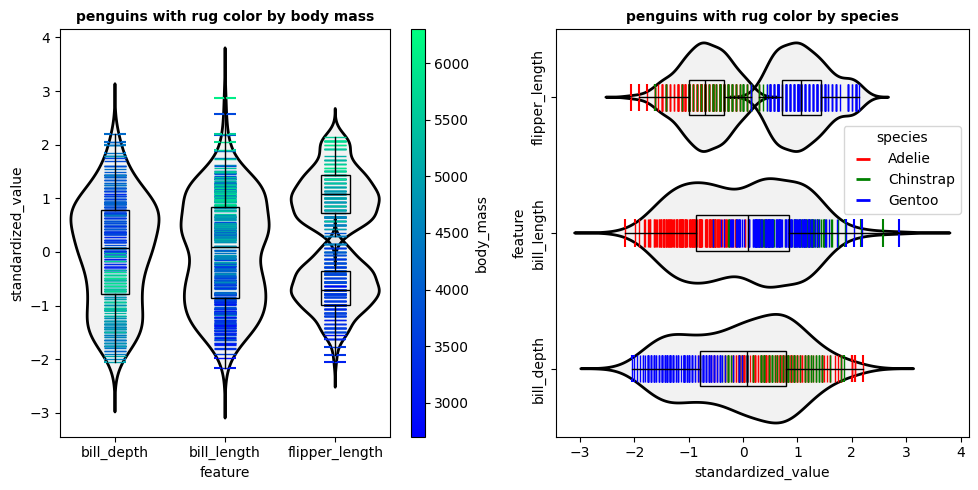

In [20]:
fig, axs = plt.subplots(1,2, figsize=(10, 5), sharey=False)
#continous rug_hue, continous seaborn palette: rug_color
r = bixplot(data=df_plt_penguins, x='feature', y='standardized_value', legend_position=[0.35,1], 
            rug_hue='body_mass', rug_color='winter', 
            rug_legend=True, rug_length=0.2,
            box_color='black', box_linewidth=1, box_width=1.3,
            density_color='black', density_alpha=0.05, density_borderlinewidth=2, ax=axs[0])
axs[0].set_title("penguins with rug color by body mass", fontweight='bold', fontsize=10)
#categorical rug_hue, discrete rug_color
r = bixplot(data=df_plt_penguins, y='feature', x='standardized_value', legend_position=[0.68,0.78], 
            rug_hue='species', rug_color=['red','green','blue'], orient='h',
            rug_legend=True, rug_length=0.2,
            box_color='black', box_linewidth=1, box_width=1.3,
            density_color='black', density_alpha=0.05, density_borderlinewidth=2, ax=axs[1])
axs[1].set_title("penguins with rug color by species", fontweight='bold', fontsize=10)
axs[1].tick_params(axis='y', rotation=90)

plt.tight_layout()
plt.savefig(os.path.join("visual","rugcolor_python.png"), dpi=300, bbox_inches='tight')

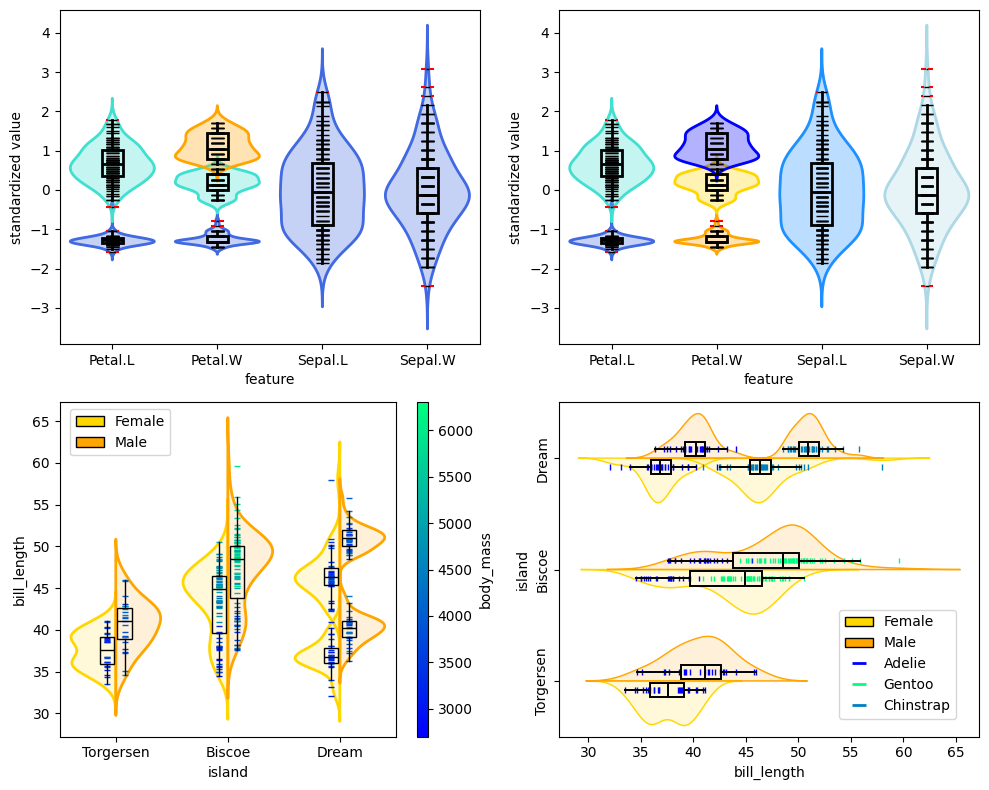

In [21]:
# The colors of the identified modes can either remain consistent across groups (the mode with the lowest mean always get assigned
# the same color, the second-highest another and so on) see figure below top left, or vary by every unique group–mode combination,
# see below figure top right. The colors of the mode are controlled by the mode_color and mode_color_by_suffix arguments. 
# Similarly to the above example, when the rug_hue argument is provided, its colors can be controlled with rug_color, for both 
# continuous (below Figure c) and categorical variables (below Figure d).
    
fig, axs = plt.subplots(2,2, figsize=(10, 8), sharey=False)

#mode_color can be set to a seaborn palette too, e.g. using mode_color='viridis'
r = bixplot(data=df_plt_iris, x='feature', y='standardized value', 
            mode_color=['royalblue','turquoise','orange','gold','blue','dodgerblue','lightblue'], 
            mode_legend=False,  mode_color_by_suffix=True,
            box_linewidth=2, rug_outer_color='red',
            density_color='mode', density_alpha=0.3, density_borderlinewidth=2, ax=axs[0,0])

# No rug
# Boxplot  in black
# Density representing the mode with each unique mode-group combination get a different value (mode_color_by_suffix=False) and
# showed in the legend at a specified position (legend_position=[-0.21,1])
r = bixplot(data=df_plt_iris, x='feature', y='standardized value',
            mode_color=['royalblue','turquoise','orange','gold','blue','dodgerblue','lightblue'], mode_legend=False,  mode_color_by_suffix=False,
            box_linewidth=2, rug_outer_color='red',
            density_color='mode', density_alpha=0.3, density_borderlinewidth=2,  ax=axs[0,1])

# Rug as a continuous variable and show legend (rug_legend=True)
# Boxplots in black
# Density representing the hue with transparent face (density_alpha=0)
r = bixplot(data=df_penguins, x='island', y='bill_length', legend_position=[0.35,1], group_order=['Torgersen', 'Biscoe', 'Dream'],
            hue='sex', hue_color={'Female':'gold', 'Male':'orange'}, hue_legend=True, split=True, 
            rug_hue='body_mass', rug_color='winter', 
            rug_legend=True, rug_length=0.2, rug_outer_color='red',
            box_linewidth=1, box_width=1.3,
            density_color='hue', density_alpha=0.15, density_borderlinewidth=2, ax=axs[1,0])

# Rug as a continuous variable and show legend (rug_legend=True)
# Boxplots in black
# Density representing the hue with transparent face (density_alpha=0)
# Orientation in horizontal mode (orient='h')
r = bixplot(data=df_penguins, y='island', x='bill_length', orient='h', legend_position=[0.65,0.4], group_order=['Torgersen', 'Biscoe', 'Dream'],
            hue='sex', hue_color={'Female':'gold', 'Male':'orange'}, hue_legend=True, split=True, 
            rug_hue='species', rug_color='winter', 
            rug_legend=True, rug_length=0.2, rug_outer_color='red',
            box_linewidth=1.4, box_width=1.3,
            density_color='hue', density_alpha=0.15, ax=axs[1,1])
axs[1,1].tick_params(axis='y', rotation=90)
plt.tight_layout()

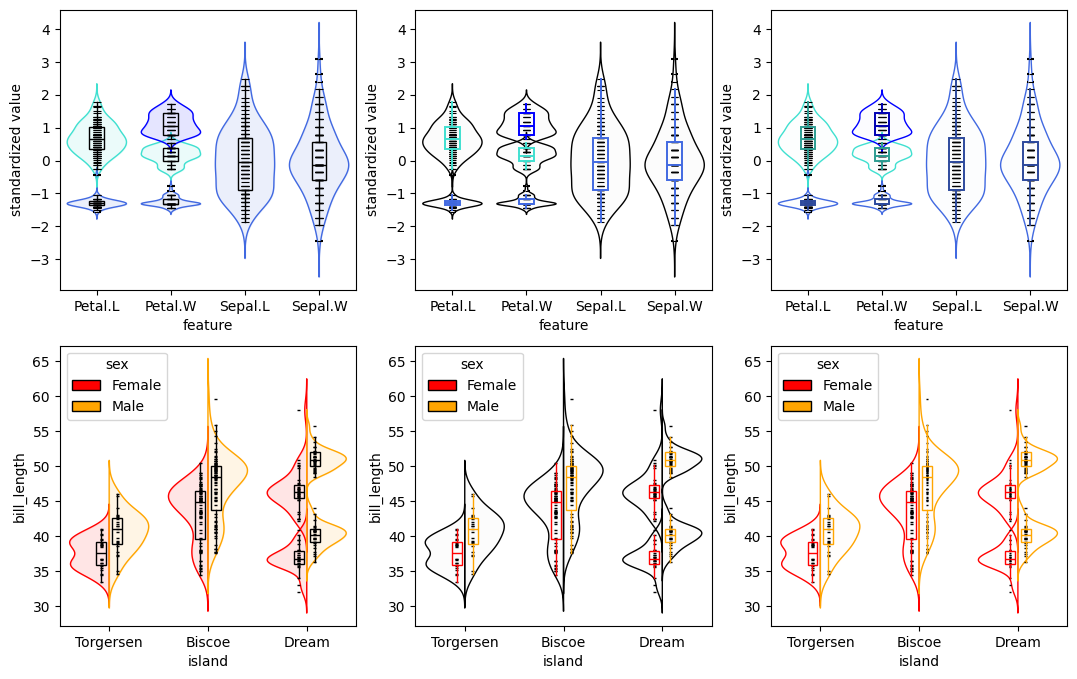

In [22]:
fig, axs = plt.subplots(2,3, figsize=(13, 8), sharey=False)

r = bixplot(data=df_plt_iris, x='feature', y='standardized value', orient='v',  
            mode_color=['royalblue','turquoise','blue'], rug_linewidths=0.8, rug_length=0.1,
            box_color='black', density_color='mode', density_alpha=0.1, ax=axs[0,0])
r = bixplot(data=df_plt_iris, x='feature', y='standardized value', orient='v',  
            mode_color=['royalblue','turquoise','blue'], rug_linewidths=0.8, rug_length=0.1,
            box_color='mode', box_linewidth=1.4, density_color='black', density_alpha=0.01, ax=axs[0,1])
r = bixplot(data=df_plt_iris, x='feature', y='standardized value', orient='v',
            mode_color=['royalblue','turquoise','blue'], rug_linewidths=0.8, rug_length=0.1,
            box_color='mode', box_linewidth=1.4, density_color='mode', density_alpha=0.01, ax=axs[0,2])

r = bixplot(data=df_penguins, x='island', y='bill_length', orient='v',  group_order=['Torgersen', 'Biscoe', 'Dream'],
            hue='sex', hue_color={'Female':'red', 'Male':'orange'}, hue_legend=True, split=True,
            mode_color=['royalblue','turquoise','blue'], 
            box_color='black', density_color='hue', density_alpha=0.1, ax=axs[1,0])
r = bixplot(data=df_penguins, x='island', y='bill_length', orient='v',  group_order=['Torgersen', 'Biscoe', 'Dream'],
            hue='sex', hue_color={'Female':'red', 'Male':'orange'}, hue_legend=True, split=True,
            mode_color=['royalblue','turquoise','blue'], 
            box_color='hue', density_color='black', density_alpha=0.01, ax=axs[1,1])
r = bixplot(data=df_penguins, x='island', y='bill_length', orient='v',  group_order=['Torgersen', 'Biscoe', 'Dream'], 
            hue='sex', hue_color={'Female':'red', 'Male':'orange'}, hue_legend=True, split=True,
            mode_color=['royalblue','turquoise','blue'],  mode_color_by_suffix=True,
            box_color='hue', density_color='hue', density_alpha=0.01, ax=axs[1,2])

# Exploring the topgear data (Fig. S1)

,feature,standardized value
0,Weight,-0.359682
1,Weight,-1.060946


(1188, 2)


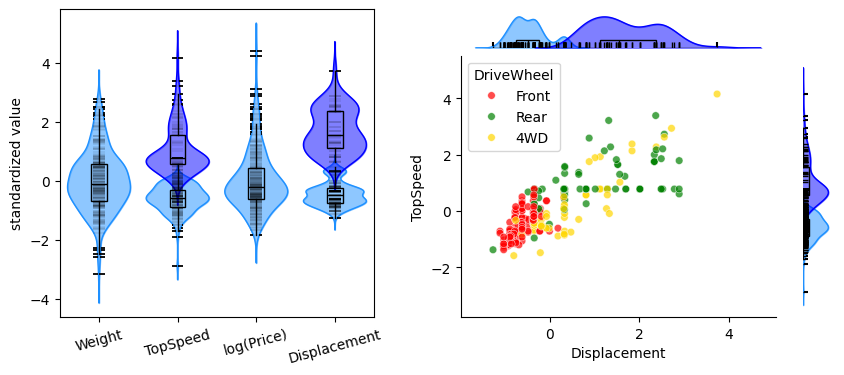

In [23]:
li_order = ['Weight', 'TopSpeed', 'log(Price)', 'Displacement']
for c in li_order:
    df_tg[c] = pd.to_numeric(df_tg[c]) #make sure its numeric and not "object"
df_tg[li_order] = (df_tg[li_order] - df_tg[li_order].mean()) / df_tg[li_order].std(ddof=1)
df_plot = df_tg[li_order].melt(var_name='feature', value_name='standardized value')
display(df_plot.head(2))
print(df_plot.shape)

fig = plt.figure(figsize=(10, 4))
gs = GridSpec(2, 4, width_ratios=[2, 0.2, 2, 0.2], height_ratios=[0.3, 2], wspace=0.16, hspace=0.05)

################### --- Left Panel: Bixplots of 4 log-scaled features ---
ax_left = fig.add_subplot(gs[:, 0])
bixplot(data=df_plot, x='feature', y='standardized value',  
        mode_color=['dodgerblue','blue','turquoise'], group_order=li_order, 
        rug_length=0.15, rug_outer_linewidths=1.3, rug_linewidths=0.1, ax=ax_left)
ax_left.set_xlabel("")
ax_left.set_xticklabels(ax_left.get_xticklabels(), rotation=15)

################### --- Right Main: log(TopSpeed) vs log(Displacement) ---
ax_main = fig.add_subplot(gs[1, 2])
sns.scatterplot(data=df_tg, x='Displacement', y='TopSpeed', hue='DriveWheel', palette=['red','green','gold'],ax=ax_main, s=30, alpha=0.7, legend=True)
sns.despine(ax=ax_main)

# --- Top Marginal: log(TopSpeed) ---
ax_top = fig.add_subplot(gs[0, 2], sharex=ax_main)
bixplot(data=df_tg, x='Displacement', orient='h', split=True, 
        mode_color=['dodgerblue','blue','turquoise'], rug_length=0.15, ax=ax_top)
ymin, ymax = ax_top.get_ylim()
cutpoint = (ymax - ymin) / 2
ax_top.set_ylim(cutpoint + ymin, ymax)
ax_top.axis('off')

# --- Right Marginal: log(Displacement) ---
ax_right = fig.add_subplot(gs[1, 3], sharey=ax_main)
bixplot(data=df_tg, y='TopSpeed', orient='v',
        mode_color=['dodgerblue','blue','turquoise'], rug_length=0.15, ax=ax_right)
xmin, xmax = ax_right.get_xlim()
cutpoint = (xmax - xmin) / 2
ax_right.set_xlim(cutpoint + xmin, xmax)
ax_right.axis('off')

################### --- Save & Show ---
plt.savefig(os.path.join("visual", "topgear_python.png"), dpi=300, bbox_inches='tight')
plt.show()

# Titanic (Fig. S4)

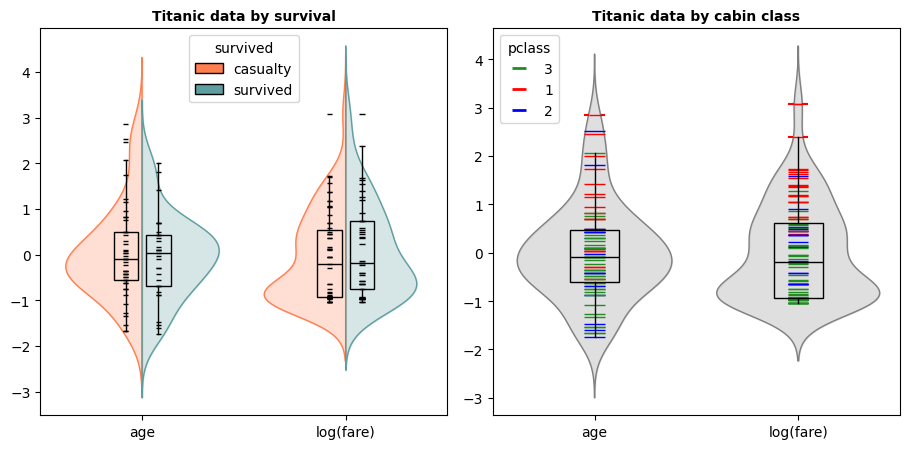

In [24]:
# --- Subset,Transform and standardize like in R example
df_titanic = df_titanic.iloc[:100, :].copy()
df_titanic['log(fare)'] = np.log(df_titanic['fare'] + 1)
df_titanic['pclass'] = df_titanic['pclass'].astype('category')
li_order = ['age', 'log(fare)']
df_titanic[li_order] = (df_titanic[li_order] - df_titanic[li_order].mean()) / df_titanic[li_order].std(ddof=1)
df_plot = df_titanic.melt(value_vars=li_order, var_name='feature', 
                          id_vars=['survived','pclass'], value_name='standardized value')
df_plot['survived'] = df_plot['survived'].map({0: 'casualty', 1: 'survived'})
df_plot['pclass'] = df_plot['pclass'].map({1: '1', 2: '2', 3: '3'})

# --- Plot
fig, axs = plt.subplots(1, 2, figsize=(9.2, 4.6))

# left side: by survival
bixplot(data=df_plot, x='feature', y='standardized value', 
        hue='survived', hue_color=['coral', 'cadetblue'], split=True, hue_legend=True,
        density_color='hue', density_alpha=0.25, density_norm='area',
        box_width=1.2, rug_length=0.10, legend_position='upper center', ax=axs[0])
axs[0].set_title('Titanic data by survival', fontsize=10, fontweight='bold')
axs[0].set_xlabel('')
axs[0].set_ylabel('')

# right side: by cabin class
bixplot(data=df_plot, x='feature', y='standardized value',
        rug_hue='pclass', rug_length=0.10, rug_color=['red', 'blue', 'forestgreen'], rug_legend=True,
        density_norm='area', density_color='grey', density_alpha=0.25,
        box_width=1.2, ax=axs[1])
axs[1].set_title('Titanic data by cabin class', fontsize=10, fontweight='bold')
axs[1].set_xlabel('')
axs[1].set_ylabel('')

plt.tight_layout()
plt.savefig(os.path.join("visual", "titanic_python.png"), dpi=300, bbox_inches='tight')
plt.show()